# Decision Tree

In [38]:
#Importamos Librerias
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [39]:
#Leer Datos en formato xlsx
df = pd.read_excel("data.xlsx")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   y       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [40]:
#Cargar Datos
X = df[["X1","X2"]]
y = df["y"]
       

In [41]:
#Division 70/30
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [42]:
#Árbol de Decisión (criterio Gini)

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,      
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

In [43]:
#Metricas
cm_tree = confusion_matrix(y_test, y_pred_tree)
tn, fp, fn, tp = cm_tree.ravel()

sens_tree = tp / (tp + fn)
esp_tree = tn / (tn + fp)
prec_tree = tp / (tp + fp)
exact_tree = (tp + tn) / (tp + tn + fp + fn)

print("=== Árbol de Decisión ===")
print("Sensibilidad:", sens_tree)
print("Especificidad:", esp_tree)
print("Precisión:", prec_tree)
print("Exactitud:", exact_tree)


=== Árbol de Decisión ===
Sensibilidad: 0.8888888888888888
Especificidad: 0.9038461538461539
Precisión: 0.8951048951048951
Exactitud: 0.8966666666666666


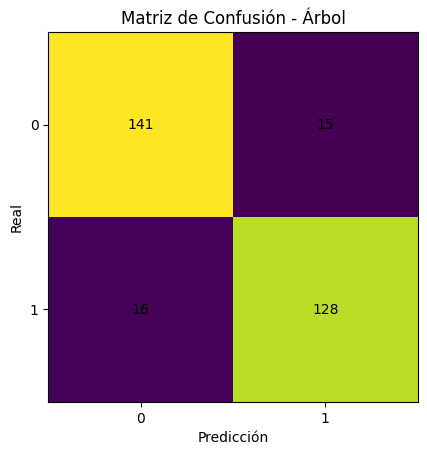

In [44]:
#Matriz de Confusion Arbol
plt.figure()
plt.imshow(cm_tree)
plt.title("Matriz de Confusión - Árbol")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_tree[i, j], ha="center", va="center")

plt.savefig("matriz_confusion_arbol.png")
plt.show()

c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


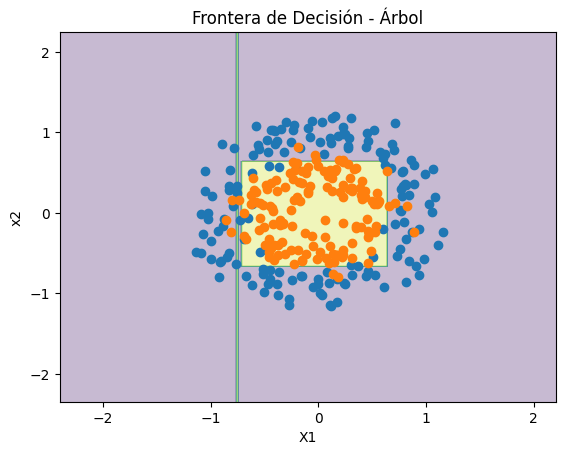

In [45]:
#Frontera de Decision
x_min, x_max = X["X1"].min() - 1, X["X1"].max() + 1
y_min, y_max = X["X2"].min() - 1, X["X2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z_tree = decision_tree.predict(grid)
Z_tree = Z_tree.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z_tree, alpha=0.3)
plt.scatter(X_test[y_test == 0]["X1"], X_test[y_test == 0]["X2"])
plt.scatter(X_test[y_test == 1]["X1"], X_test[y_test == 1]["X2"])
plt.title("Frontera de Decisión - Árbol")
plt.xlabel("X1")
plt.ylabel("x2")
plt.savefig("frontera_decision_arbol.png")
plt.show()

In [46]:
#Diagrama del Arbol
plt.figure(figsize=(12,8))
plot_tree(
    decision_tree,
    feature_names=["X1", "X2"],
    class_names=["Clase 0", "Clase 1"],
    filled=True
)
plt.savefig("diagrama_arbol.png")
plt.close()


### INTERPRETACIÓN

Podemos Ver que, a diferencia de la regresión Logística, los árboles de decisión segmentan de mejor manera ambas clases, esto, debido a que pueden hacer más cortes de los datos, dejando claro a que espacio pertenece mayoritariamente una clase